In [1]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'silver_daily_ohlcv_2000_2025.csv', 'silver_sentiment_weekly.csv', 'silver_supply_demand_annual.csv', 'silver_futures_contracts.csv', 'silver_macroeconomic_monthly.csv', 'sample_data']


In [2]:
import pandas as pd

ohlcv = pd.read_csv("silver_daily_ohlcv_2000_2025.csv")
macro = pd.read_csv("silver_macroeconomic_monthly.csv")
futures = pd.read_csv("silver_futures_contracts.csv")
sentiment = pd.read_csv("silver_sentiment_weekly.csv")
supply = pd.read_csv("silver_supply_demand_annual.csv")

In [3]:
print(ohlcv.head())
print(macro.head())
print(futures.head())
print(sentiment.head())
print(supply.head())

         Date    Open    High     Low   Close  Adj_Close  Volume    VWAP  \
0  2000-01-03  5.1962  5.1962  5.1884  5.1910     5.1910   36286  5.1919   
1  2000-01-04  5.1084  5.1084  5.0848  5.0980     5.0980   35819  5.0971   
2  2000-01-05  5.1388  5.1464  5.1388  5.1412     5.1412   38844  5.1421   
3  2000-01-06  5.2123  5.2291  5.2123  5.2239     5.2239   24445  5.2218   
4  2000-01-07  5.2766  5.2832  5.2766  5.2779     5.2779   40020  5.2792   

   Returns_Pct  Log_Returns  Dollar_Change  Intraday_Range  Intraday_Range_Pct  
0      -0.1729    -0.001731        -0.0090          0.0078              0.1511  
1      -1.7916    -0.018079        -0.0930          0.0236              0.4649  
2       0.8480     0.008444         0.0432          0.0076              0.1472  
3       1.6076     0.015948         0.0826          0.0168              0.3225  
4       1.0344     0.010291         0.0540          0.0066              0.1251  
         Date  Silver_Price_USD  Gold_Price_USD  Silver_G

In [4]:
print("OHLCV Shape:", ohlcv.shape)
print("Macro Shape:", macro.shape)
print("Futures Shape:", futures.shape)
print("Sentiment Shape:", sentiment.shape)
print("Supply Shape:", supply.shape)

OHLCV Shape: (6783, 13)
Macro Shape: (312, 19)
Futures Shape: (27390, 11)
Sentiment Shape: (1043, 16)
Supply Shape: (26, 20)


In [5]:
print(ohlcv.columns)
print(macro.columns)
print(futures.columns)
print(sentiment.columns)
print(supply.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'VWAP',
       'Returns_Pct', 'Log_Returns', 'Dollar_Change', 'Intraday_Range',
       'Intraday_Range_Pct'],
      dtype='object')
Index(['Date', 'Silver_Price_USD', 'Gold_Price_USD', 'Silver_Gold_Ratio',
       'Fed_Funds_Rate', 'US_10Y_Yield', 'Real_Interest_Rate', 'US_CPI_Index',
       'US_CPI_YoY_Pct', 'DXY_Index', 'Crude_Oil_WTI', 'VIX_Index',
       'US_M2_Supply_Trillions', 'India_Repo_Rate', 'USD_INR',
       'Silver_Price_INR_Per_Kg', 'Global_PMI', 'US_Unemployment_Rate',
       'ETF_Silver_Holdings_MOz'],
      dtype='object')
Index(['Trade_Date', 'Contract_Month', 'Months_To_Expiry', 'Spot_Price',
       'Futures_Price', 'Basis', 'Basis_Pct', 'Open_Interest', 'Volume',
       'Settlement_Price', 'Implied_Carry_Rate_Annual'],
      dtype='object')
Index(['Week_Ending', 'Silver_Price_Close', 'CFTC_Commercial_Long',
       'CFTC_Commercial_Short', 'CFTC_Commercial_Net',
       'CFTC_NonCommercial_Long', 'CF

In [6]:
ohlcv.isnull().sum()
macro.isnull().sum()
futures.isnull().sum()
sentiment.isnull().sum()
supply.isnull().sum()

,0
Year,0
Mine_Production_MOz,0
Scrap_Supply_MOz,0
Net_Hedging_Supply_MOz,0
Total_Supply_MOz,0
Industrial_Demand_MOz,0
Jewelry_Demand_MOz,0
Investment_Demand_MOz,0
Photography_Demand_MOz,0
Silverware_Demand_MOz,0


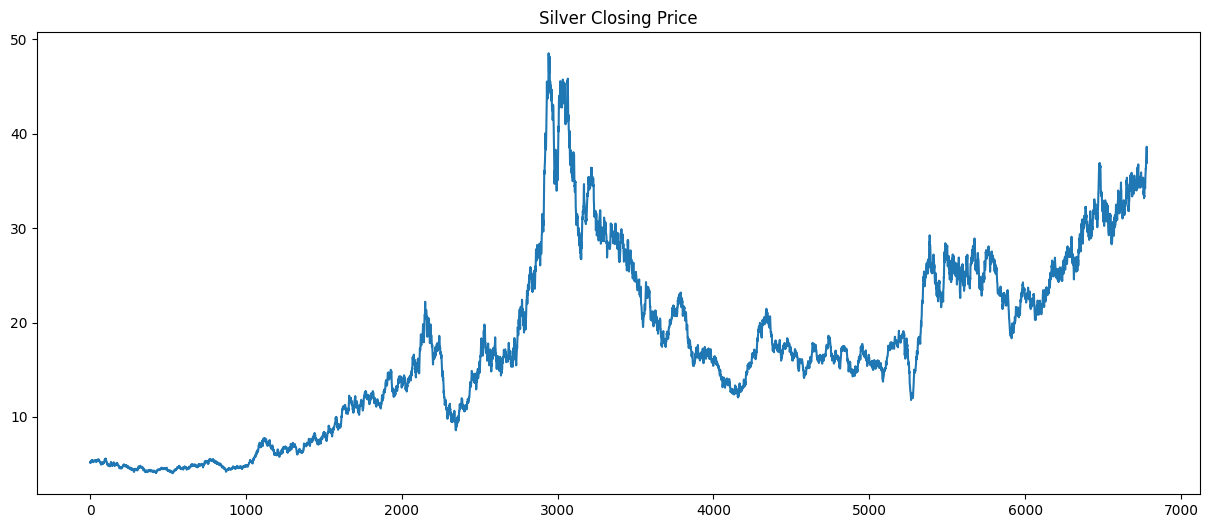

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(ohlcv["Close"])
plt.title("Silver Closing Price")
plt.show()

📈 Silver Price Trend Analysis
### Insights

- Silver prices exhibit significant volatility over the 2000–2025 period.
- A major bullish trend is observed between 2008 and 2011, where prices reached historical highs.
- Following the peak, silver experienced a prolonged correction phase, reflecting cyclical commodity market behavior.
- Several sharp upward and downward movements indicate sensitivity to economic events and investor sentiment.
- The presence of long-term trends and cyclical patterns suggests that forecasting models may effectively capture future price movements.

In [8]:
ohlcv['Date'] = pd.to_datetime(ohlcv['Date'])
macro['Date'] = pd.to_datetime(macro['Date'])
futures['Trade_Date'] = pd.to_datetime(futures['Trade_Date'])
sentiment['Week_Ending'] = pd.to_datetime(sentiment['Week_Ending'])

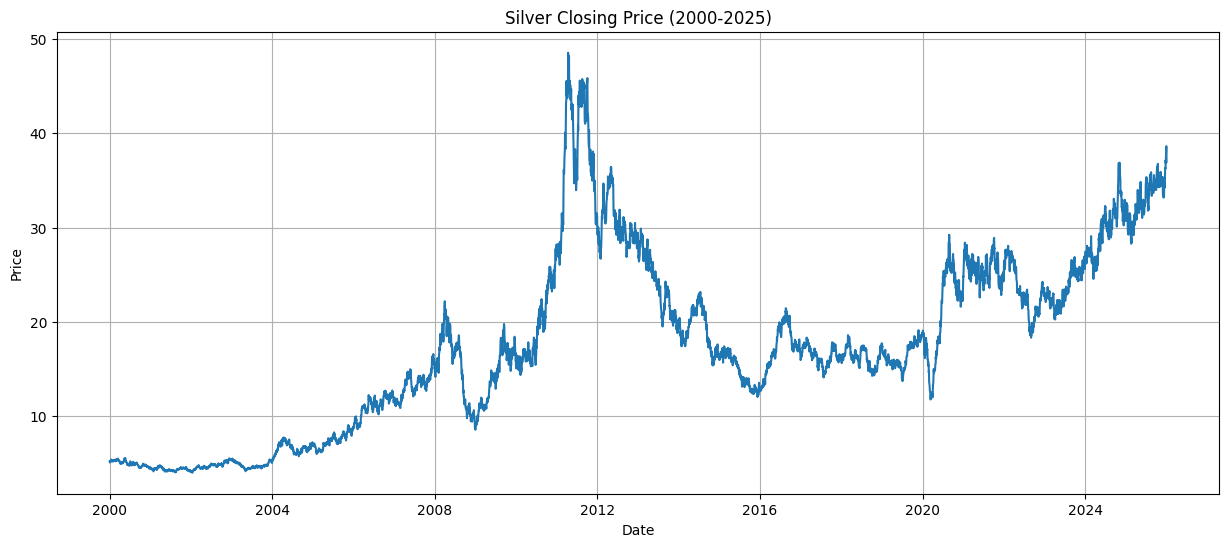

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(ohlcv['Date'], ohlcv['Close'])
plt.title("Silver Closing Price (2000-2025)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

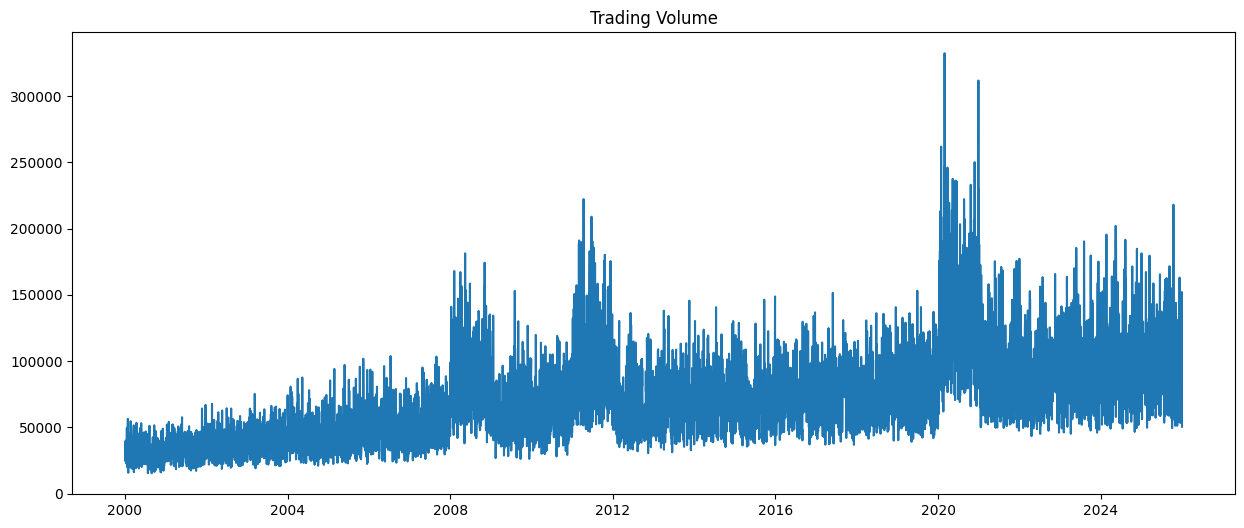

In [10]:
plt.figure(figsize=(15,6))
plt.plot(ohlcv['Date'], ohlcv['Volume'])
plt.title("Trading Volume")
plt.show()

📊 Volume Analysis
### Insights

- Trading volume fluctuates considerably over time, indicating varying levels of market participation.
- Periods of increased volume often coincide with significant price movements.
- High trading activity reflects increased investor interest and market liquidity.
- Volume can serve as a useful indicator for identifying strong market trends.
- Changes in trading volume may provide additional predictive information for forecasting models.

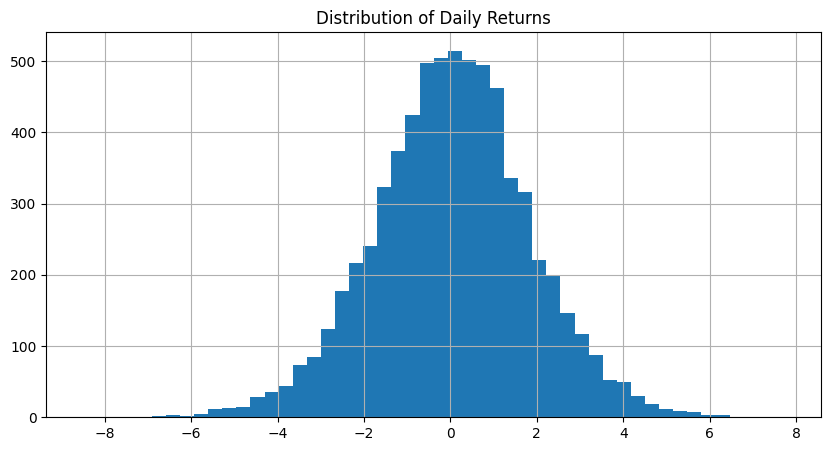

In [11]:
plt.figure(figsize=(10,5))
ohlcv['Returns_Pct'].hist(bins=50)
plt.title("Distribution of Daily Returns")
plt.show()

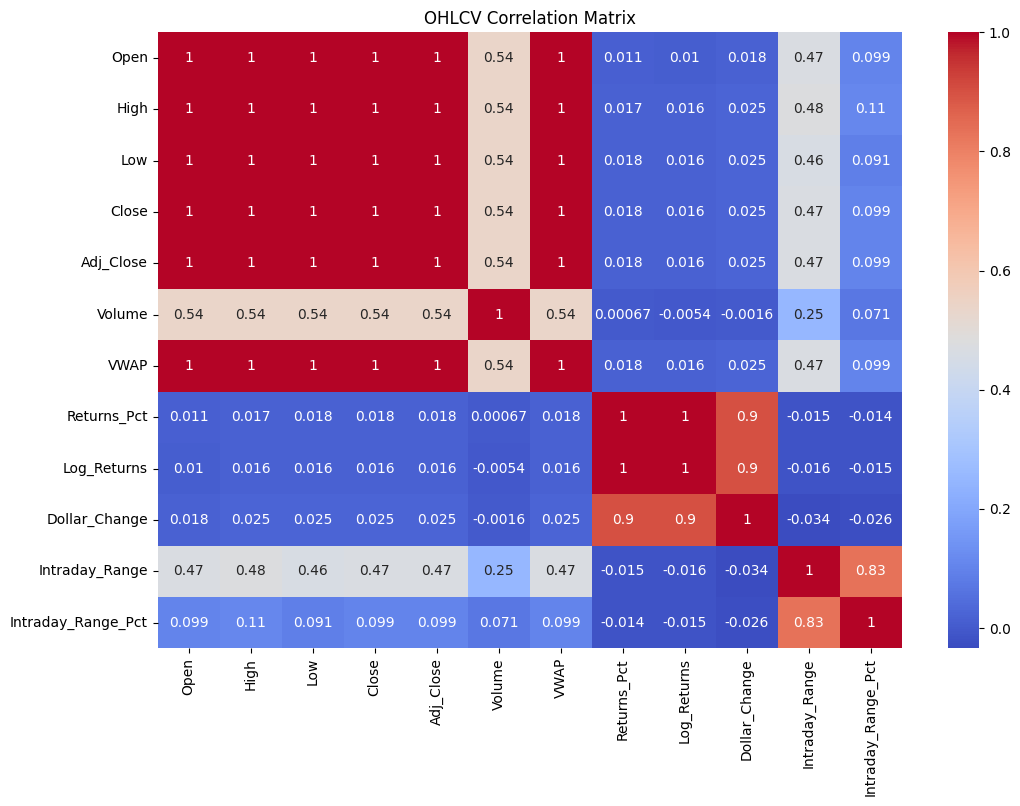

In [12]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    ohlcv.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("OHLCV Correlation Matrix")
plt.show()

🔥 OHLCV Correlation Heatmap
### Insights

- Open, High, Low, and Close prices exhibit very strong positive correlations with one another.
- The strong relationship among price variables confirms consistency in daily market movements.
- VWAP closely tracks market prices and may serve as a useful forecasting feature.
- Volume shows a weaker relationship with price variables compared to OHLC features.
- The high correlation among price variables indicates potential redundancy that should be considered during feature selection.

In [13]:
merged = pd.merge(
    ohlcv[['Date','Close']],
    macro,
    on='Date',
    how='inner'
)

In [14]:
merged.shape

(222, 20)

In [15]:
corr = merged.corr(numeric_only=True)

corr['Close'].sort_values(
    ascending=False
)

,Close
Close,1.000000
Silver_Price_USD,0.961034
Silver_Price_INR_Per_Kg,0.938351
Gold_Price_USD,0.930703
ETF_Silver_Holdings_MOz,0.729544
USD_INR,0.707741
US_CPI_Index,0.683991
US_M2_Supply_Trillions,0.651818
Crude_Oil_WTI,0.624617
India_Repo_Rate,0.140938


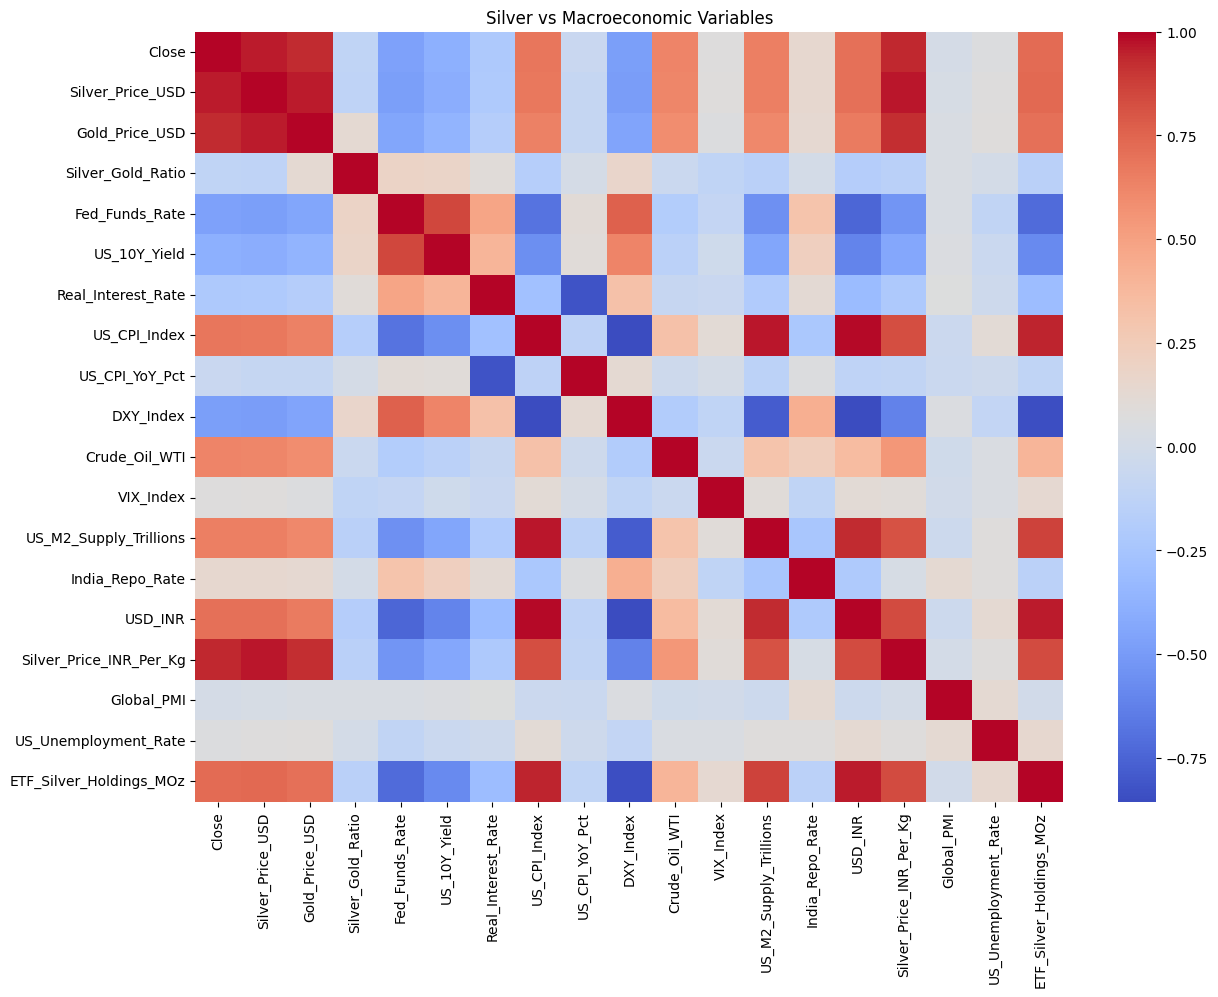

In [16]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title("Silver vs Macroeconomic Variables")

plt.show()

🌎 Macroeconomic Analysis
### Insights

- Gold Price exhibits a strong positive relationship with Silver Price, indicating that both precious metals often move together.
- ETF Silver Holdings show a significant positive correlation, highlighting the impact of institutional investment demand.
- Inflation indicators such as CPI and Money Supply demonstrate positive relationships with silver prices.
- The DXY Index shows the strongest negative correlation, suggesting that a stronger US Dollar negatively affects silver prices.
- Interest rates and bond yields exhibit negative relationships with silver, supporting its role as a non-yielding asset.

In [17]:
ohlcv.describe()

,Date,Open,High,Low,Close,Adj_Close,Volume,VWAP,Returns_Pct,Log_Returns,Dollar_Change,Intraday_Range,Intraday_Range_Pct
count,6783,6783.000000,6783.000000,6783.000000,6783.000000,6783.000000,6783.000000,6783.000000,6783.000000,6783.000000,6783.000000,6783.000000,6783.000000
mean,2012-12-31 14:24:15.285272064,17.527052,17.603426,17.455197,17.527283,17.527283,71737.569365,17.528635,0.045239,0.000289,0.004683,0.148229,0.808749
min,2000-01-03 00:00:00,4.022400,4.022400,4.018300,4.018400,4.018400,15375.000000,4.019700,-8.541000,-0.089280,-2.298900,0.004200,0.100000
25%,2006-07-03 12:00:00,10.547450,10.607050,10.480750,10.553500,10.553500,46089.500000,10.543950,-1.096400,-0.011024,-0.156200,0.031600,0.234950
50%,2013-01-01 00:00:00,16.634000,16.691200,16.565600,16.604700,16.604700,65879.000000,16.626700,0.070200,0.000702,0.007600,0.077600,0.534800
75%,2019-07-02 12:00:00,24.244500,24.347400,24.103500,24.227750,24.227750,91101.500000,24.209700,1.183300,0.011764,0.175150,0.185850,1.076150
max,2025-12-31 00:00:00,48.515800,49.333300,48.515800,48.536800,48.536800,332301.000000,48.662800,7.764200,0.074776,2.542100,2.717300,11.122300
std,NaN,9.397944,9.444507,9.352822,9.397174,9.397174,34541.688463,9.397863,1.806171,0.018070,0.383069,0.196219,0.827428


In [18]:
macro.describe()

,Date,Silver_Price_USD,Gold_Price_USD,Silver_Gold_Ratio,Fed_Funds_Rate,US_10Y_Yield,Real_Interest_Rate,US_CPI_Index,US_CPI_YoY_Pct,DXY_Index,Crude_Oil_WTI,VIX_Index,US_M2_Supply_Trillions,India_Repo_Rate,USD_INR,Silver_Price_INR_Per_Kg,Global_PMI,US_Unemployment_Rate,ETF_Silver_Holdings_MOz
count,312,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000
mean,2012-12-15 17:23:04.615384576,17.564423,1224.202051,69.961859,3.374583,4.900801,-0.207917,282.021474,3.582756,98.791923,58.241538,15.605224,11.925369,6.135962,65.472115,39834.750000,50.010577,5.528205,450.931090
min,2000-01-01 00:00:00,4.350000,252.560000,55.020000,1.720000,2.280000,-4.190000,169.000000,1.210000,86.510000,15.000000,9.000000,4.624000,3.690000,40.540000,5998.000000,42.000000,3.500000,0.000000
25%,2006-06-23 12:00:00,10.890000,776.292500,63.130000,2.407500,4.117500,-1.375000,215.325000,2.297500,94.432500,40.347500,11.482500,6.800000,5.820000,53.937500,19720.500000,47.700000,4.400000,302.650000
50%,2012-12-16 12:00:00,16.830000,1174.955000,70.355000,3.270000,4.885000,-0.225000,272.000000,3.590000,100.240000,57.335000,15.105000,9.876000,6.165000,65.440000,38154.500000,49.850000,5.500000,507.350000
75%,2019-06-08 12:00:00,23.940000,1645.565000,77.162500,3.990000,5.682500,0.990000,344.500000,4.790000,102.850000,75.172500,18.132500,14.558750,6.550000,77.277500,60234.500000,52.125000,6.500000,697.925000
max,2025-12-01 00:00:00,48.500000,3460.460000,84.950000,5.470000,7.740000,3.810000,435.000000,5.960000,109.630000,108.750000,70.870000,27.525000,7.810000,89.150000,97075.000000,59.200000,9.900000,941.400000
std,NaN,9.146717,649.580694,8.659312,0.927999,1.099912,1.621284,76.861967,1.409073,5.867508,23.194989,6.311604,6.488885,0.705012,13.554288,24697.444518,3.093212,1.391212,290.943723


In [19]:
corr_futures = futures.corr(numeric_only=True)

corr_futures

,Months_To_Expiry,Spot_Price,Futures_Price,Basis,Basis_Pct,Open_Interest,Volume,Settlement_Price,Implied_Carry_Rate_Annual
Months_To_Expiry,1.000000e+00,-1.161597e-15,0.009000,0.309890,0.330727,-0.004659,-0.003209,0.009014,0.002178
Spot_Price,-1.161597e-15,1.000000e+00,0.999587,0.146676,0.008710,0.266254,0.177833,0.999564,0.006630
Futures_Price,9.000214e-03,9.995872e-01,1.000000,0.175034,0.035635,0.266102,0.177804,0.999978,0.025138
Basis,3.098903e-01,1.466762e-01,0.175034,1.000000,0.928487,0.037615,0.027621,0.175098,0.638319
Basis_Pct,3.307273e-01,8.709503e-03,0.035635,0.928487,1.000000,0.001171,0.003995,0.035720,0.689144
Open_Interest,-4.658726e-03,2.662536e-01,0.266102,0.037615,0.001171,1.000000,0.675187,0.266112,0.006335
Volume,-3.209131e-03,1.778328e-01,0.177804,0.027621,0.003995,0.675187,1.000000,0.177802,0.004240
Settlement_Price,9.014023e-03,9.995637e-01,0.999978,0.175098,0.035720,0.266112,0.177802,1.000000,0.025158
Implied_Carry_Rate_Annual,2.177647e-03,6.629627e-03,0.025138,0.638319,0.689144,0.006335,0.004240,0.025158,1.000000


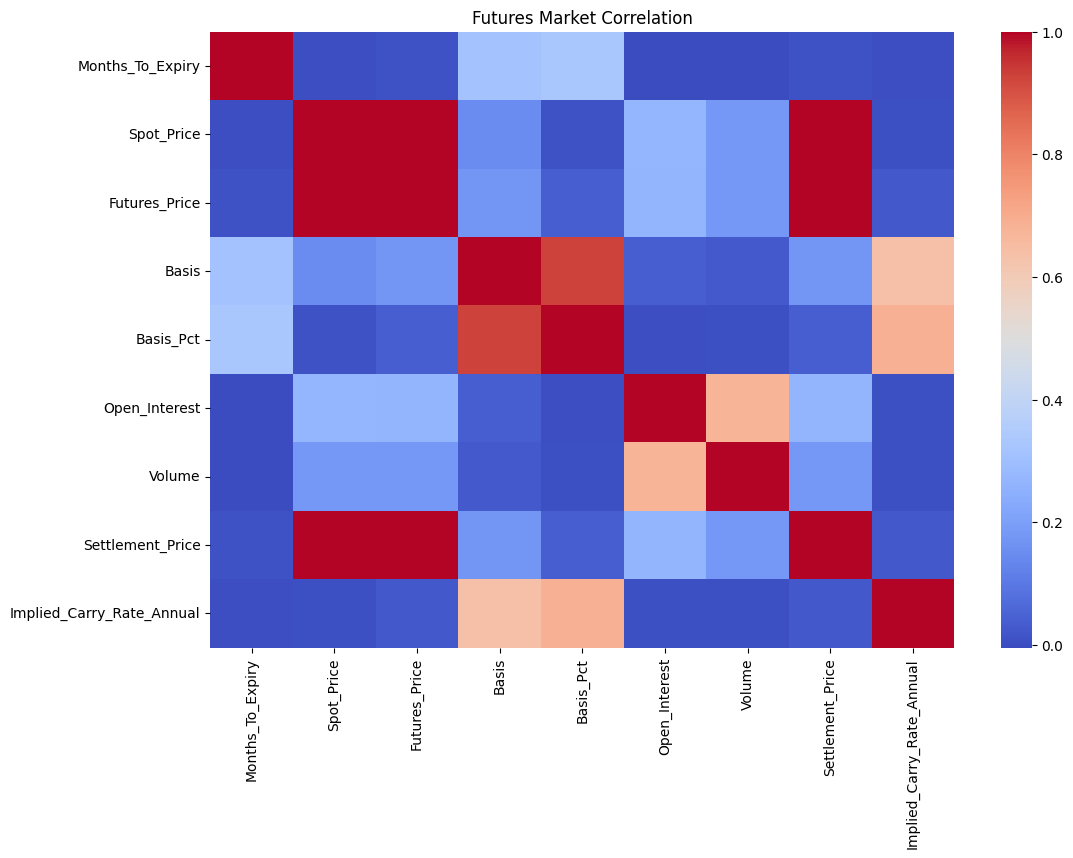

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_futures,
    cmap='coolwarm'
)

plt.title("Futures Market Correlation")

plt.show()

📉 Futures Market Analysis
### Insights

- Spot Prices and Futures Prices move almost identically, indicating strong market efficiency.
- Settlement Prices closely follow Futures Prices and Spot Prices.
- Basis and Basis Percentage exhibit strong positive relationships, reflecting market expectations.
- Open Interest and Trading Volume show a strong positive correlation, indicating increased participation during active market periods.
- Futures market indicators provide valuable information regarding market sentiment and future expectations.

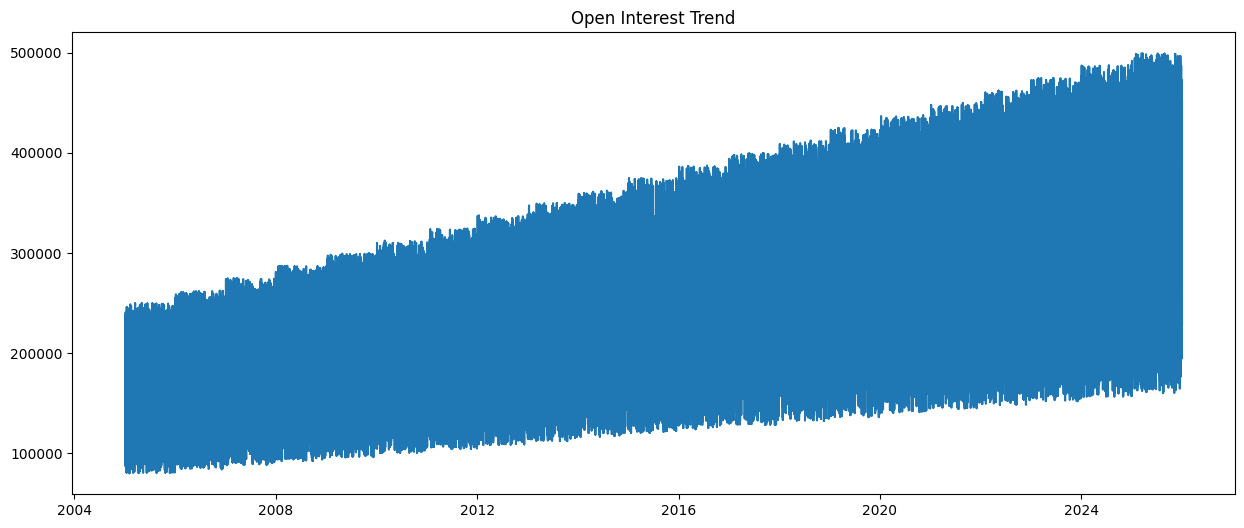

In [21]:
futures['Trade_Date'] = pd.to_datetime(
    futures['Trade_Date']
)

plt.figure(figsize=(15,6))

plt.plot(
    futures['Trade_Date'],
    futures['Open_Interest']
)

plt.title("Open Interest Trend")

plt.show()

In [22]:
plt.savefig(
    "futures_open_interest.png",
    dpi=300
)

<Figure size 640x480 with 0 Axes>

In [23]:
corr_sentiment = sentiment.corr(numeric_only=True)

corr_sentiment

,Silver_Price_Close,CFTC_Commercial_Long,CFTC_Commercial_Short,CFTC_Commercial_Net,CFTC_NonCommercial_Long,CFTC_NonCommercial_Short,CFTC_NonCommercial_Net,CFTC_Total_Open_Interest,News_Sentiment_Score,Social_Media_Mentions,Google_Trends_Index,Put_Call_Ratio,Implied_Volatility_30D,ETF_SLV_Flow_Millions,Retail_Bullion_Premium_Pct
Silver_Price_Close,1.000000,0.024082,-0.008247,0.021843,0.040121,0.092835,-0.032118,0.062780,-0.042594,0.312668,0.134264,0.019520,-0.012354,0.014751,0.074183
CFTC_Commercial_Long,0.024082,1.000000,-0.000632,0.646200,0.008845,-0.022045,0.021054,0.530763,0.036329,-0.008137,-0.002507,0.047611,0.001269,-0.022001,-0.004887
CFTC_Commercial_Short,-0.008247,-0.000632,1.000000,-0.763576,-0.022542,-0.036182,0.007471,0.608731,-0.059102,-0.015122,0.024653,-0.046972,0.005856,-0.012898,-0.023050
CFTC_Commercial_Net,0.021843,0.646200,-0.763576,1.000000,0.022915,0.013378,0.007893,-0.121842,0.068563,0.006287,-0.020433,0.066590,-0.003650,-0.004363,0.014436
CFTC_NonCommercial_Long,0.040121,0.008845,-0.022542,0.022915,1.000000,-0.028782,0.749899,0.422537,-0.037373,0.054994,-0.036757,0.001789,0.011194,0.058460,-0.025149
CFTC_NonCommercial_Short,0.092835,-0.022045,-0.036182,0.013378,-0.028782,1.000000,-0.682862,0.354230,0.051182,0.068915,-0.027360,0.026891,0.008332,0.017927,0.021383
CFTC_NonCommercial_Net,-0.032118,0.021054,0.007471,0.007893,0.749899,-0.682862,1.000000,0.074372,-0.061187,-0.005417,-0.008756,-0.016490,0.002667,0.030861,-0.032532
CFTC_Total_Open_Interest,0.062780,0.530763,0.608731,-0.121842,0.422537,0.354230,0.074372,1.000000,-0.013990,0.038140,-0.013022,0.007359,0.012704,0.013170,-0.019791
News_Sentiment_Score,-0.042594,0.036329,-0.059102,0.068563,-0.037373,0.051182,-0.061187,-0.013990,1.000000,-0.003542,0.022890,-0.029076,-0.033953,0.000404,-0.026377
Social_Media_Mentions,0.312668,-0.008137,-0.015122,0.006287,0.054994,0.068915,-0.005417,0.038140,-0.003542,1.000000,0.017918,-0.020538,-0.024098,-0.004944,-0.007675


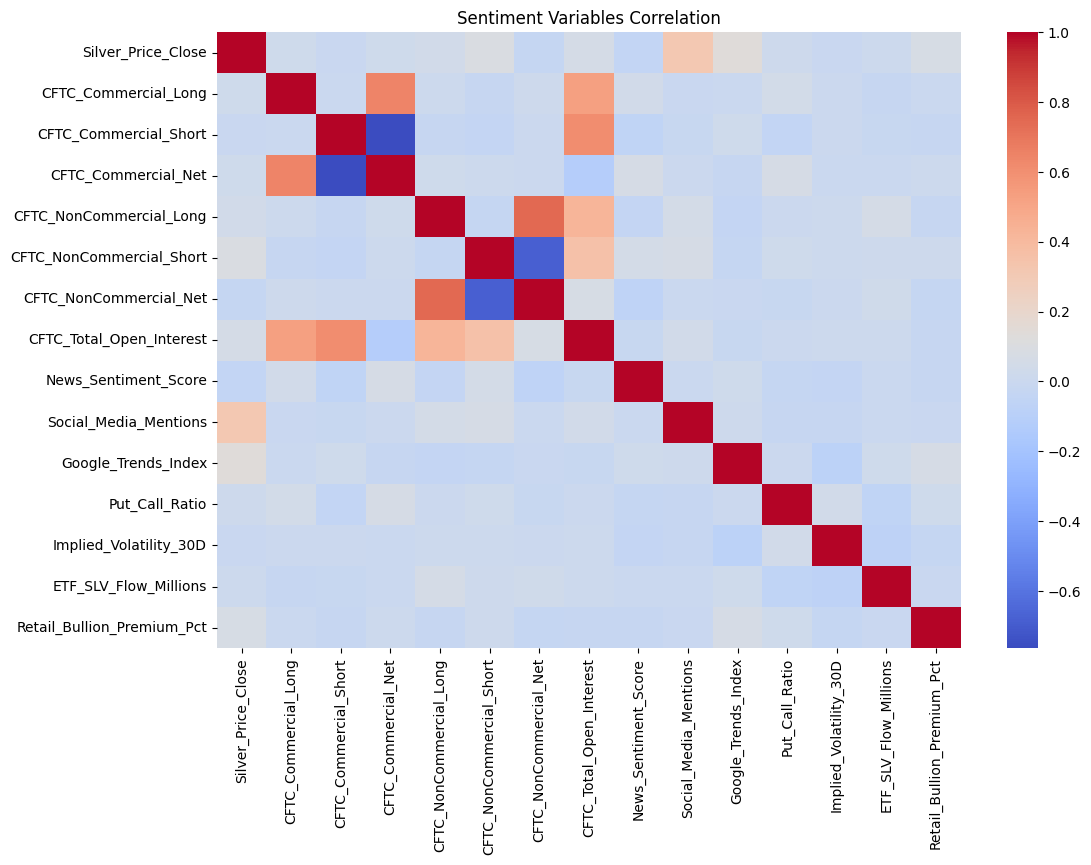

In [24]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_sentiment,
    cmap='coolwarm'
)

plt.title("Sentiment Variables Correlation")

plt.show()

📰 Sentiment Analysis
### Insights

- Social Media Mentions exhibit the strongest positive relationship with silver prices among sentiment indicators.
- Google Trends activity increases during periods of heightened market interest.
- Retail Bullion Premiums show a slight positive relationship with silver prices.
- News Sentiment Score demonstrates a relatively weak direct relationship with price movements.
- Sentiment indicators may provide supplementary predictive power when combined with macroeconomic and market variables.

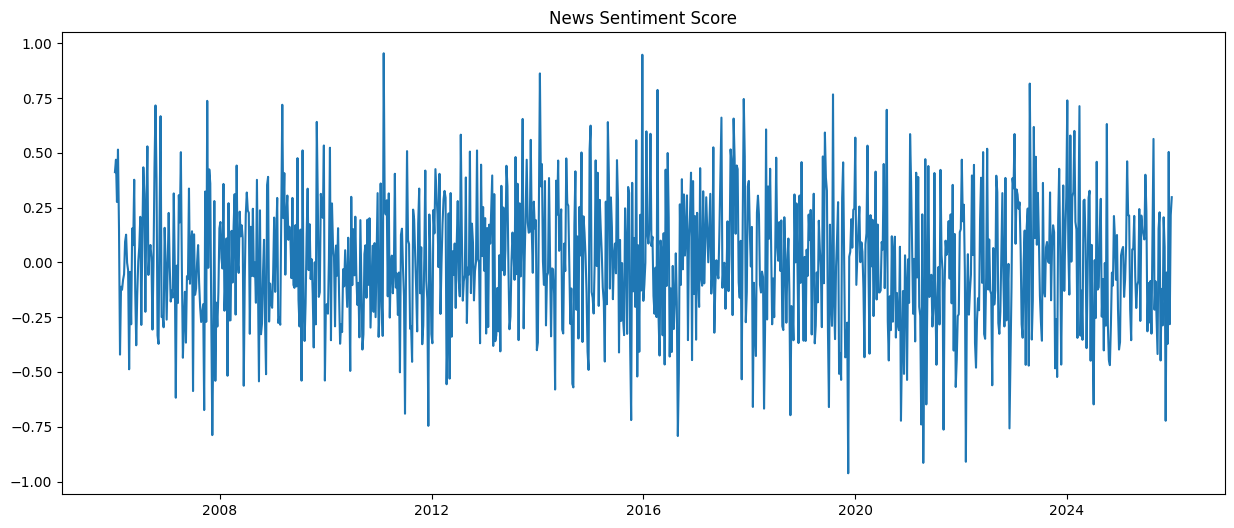

In [25]:
sentiment['Week_Ending'] = pd.to_datetime(
    sentiment['Week_Ending']
)

plt.figure(figsize=(15,6))

plt.plot(
    sentiment['Week_Ending'],
    sentiment['News_Sentiment_Score']
)

plt.title("News Sentiment Score")

plt.show()

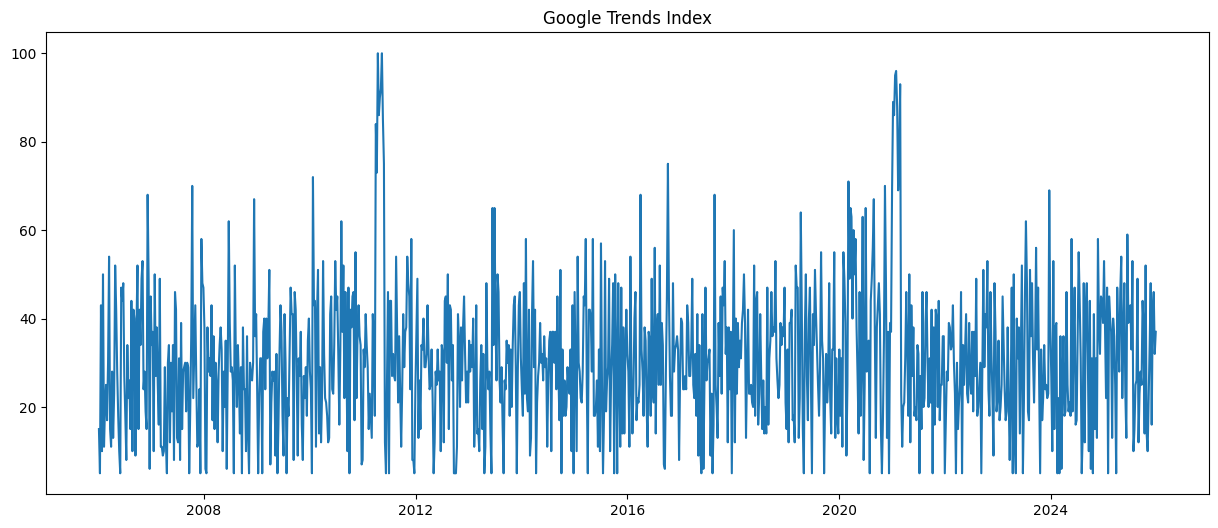

In [26]:
plt.figure(figsize=(15,6))

plt.plot(
    sentiment['Week_Ending'],
    sentiment['Google_Trends_Index']
)

plt.title("Google Trends Index")

plt.show()

In [27]:
corr_supply = supply.corr(numeric_only=True)

corr_supply

,Year,Mine_Production_MOz,Scrap_Supply_MOz,Net_Hedging_Supply_MOz,Total_Supply_MOz,Industrial_Demand_MOz,Jewelry_Demand_MOz,Investment_Demand_MOz,Photography_Demand_MOz,Silverware_Demand_MOz,Total_Demand_MOz,Supply_Demand_Balance_MOz,Avg_Price_USD_Oz,Top_Producer_Mexico_MOz,Top_Producer_Peru_MOz,Top_Producer_China_MOz,Solar_Panel_Demand_MOz,EV_Demand_MOz,COMEX_Warehouse_Stocks_MOz,LBMA_Vault_Holdings_MOz
Year,1.000000,0.849325,0.093512,0.075133,0.720192,0.961956,-0.375530,-0.045362,-0.972756,-0.150001,0.659708,-0.245052,0.748867,0.555089,-0.001038,0.189959,0.940032,0.831229,0.390014,0.881482
Mine_Production_MOz,0.849325,1.000000,0.109714,-0.051863,0.853566,0.836710,-0.312264,-0.242959,-0.824605,-0.260220,0.448656,0.032131,0.547285,0.533349,0.260832,0.184208,0.840449,0.759350,0.398996,0.686470
Scrap_Supply_MOz,0.093512,0.109714,1.000000,0.043477,0.581050,0.092353,-0.146427,-0.355769,-0.138383,-0.161857,-0.185604,0.497070,0.028524,0.079249,0.189269,-0.163684,0.128029,0.111228,0.125990,0.167470
Net_Hedging_Supply_MOz,0.075133,-0.051863,0.043477,1.000000,0.001802,0.118243,-0.145259,0.355185,-0.050370,0.135029,0.311158,-0.300202,0.057050,0.019322,-0.087894,-0.140070,0.060881,0.012406,0.233992,0.135310
Total_Supply_MOz,0.720192,0.853566,0.581050,0.001802,1.000000,0.708674,-0.323511,-0.424901,-0.722753,-0.351879,0.222470,0.331066,0.426550,0.500608,0.280355,0.091879,0.722701,0.620380,0.404418,0.640406
Industrial_Demand_MOz,0.961956,0.836710,0.092353,0.118243,0.708674,1.000000,-0.306390,-0.029499,-0.908544,-0.132037,0.738752,-0.327817,0.685756,0.534165,-0.058722,0.256615,0.972426,0.910527,0.357183,0.876693
Jewelry_Demand_MOz,-0.375530,-0.312264,-0.146427,-0.145259,-0.323511,-0.306390,1.000000,-0.102116,0.427709,-0.118235,-0.133736,-0.047315,-0.302517,-0.483260,-0.135856,0.232670,-0.324080,-0.267765,0.038286,-0.397048
Investment_Demand_MOz,-0.045362,-0.242959,-0.355769,0.355185,-0.424901,-0.029499,-0.102116,1.000000,0.089954,0.491251,0.613496,-0.825893,0.132866,-0.063509,-0.274854,-0.136018,-0.042164,0.020758,-0.237798,0.069022
Photography_Demand_MOz,-0.972756,-0.824605,-0.138383,-0.050370,-0.722753,-0.908544,0.427709,0.089954,1.000000,0.129311,-0.564773,0.151757,-0.735614,-0.606589,-0.053549,-0.165414,-0.877495,-0.745548,-0.370451,-0.844993
Silverware_Demand_MOz,-0.150001,-0.260220,-0.161857,0.135029,-0.351879,-0.132037,-0.118235,0.491251,0.129311,1.000000,0.280316,-0.463748,-0.253651,-0.107034,-0.205924,-0.206732,-0.050301,-0.044838,-0.334060,-0.220070


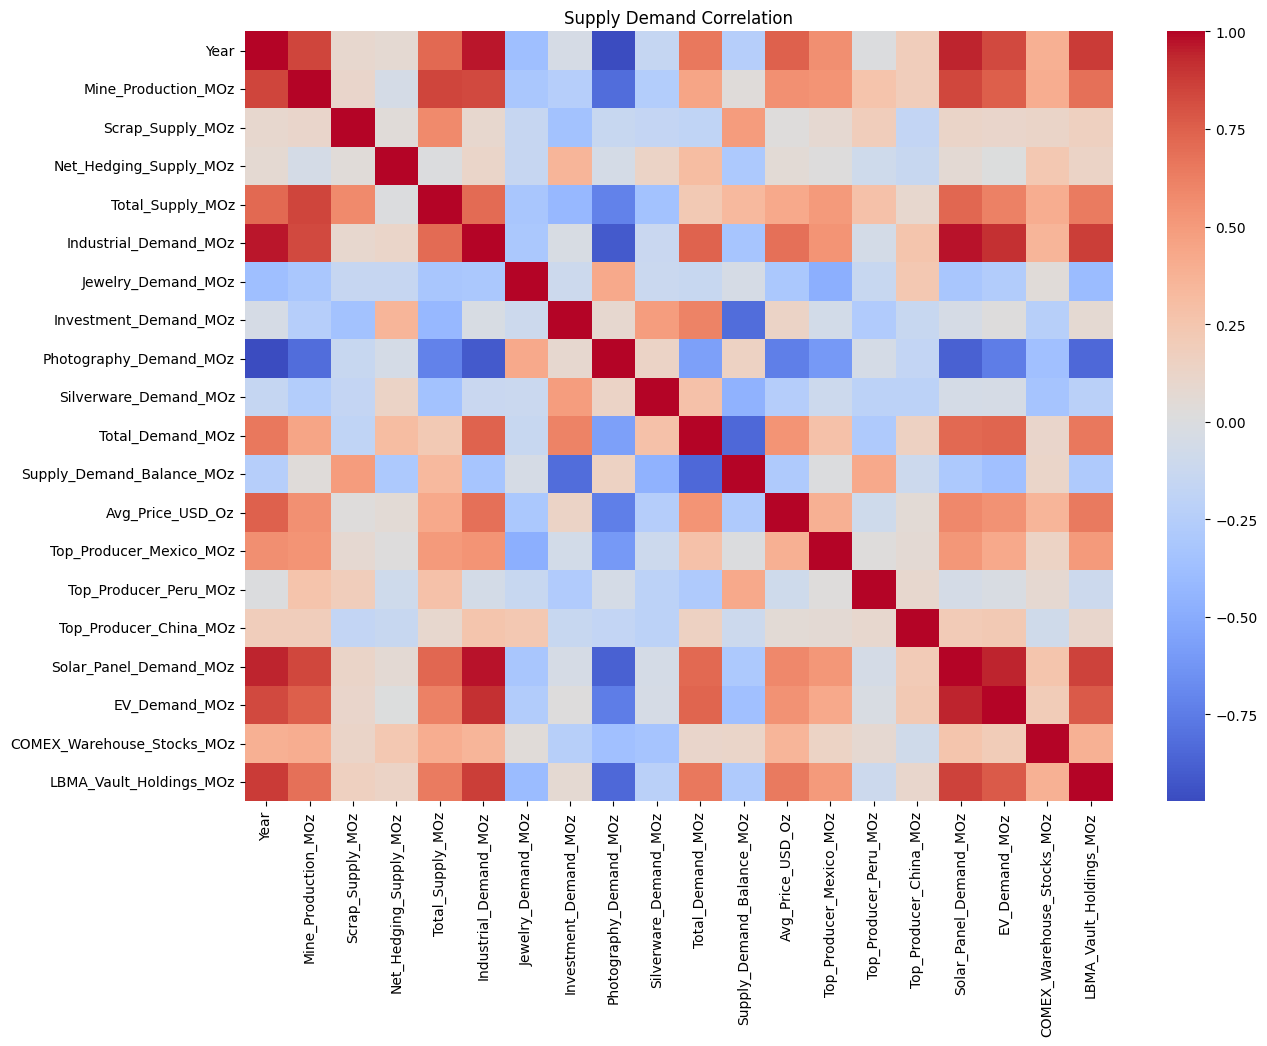

In [28]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_supply,
    cmap='coolwarm'
)

plt.title("Supply Demand Correlation")

plt.show()

⚙️ Supply-Demand Analysis
### Insights

- Industrial Demand exhibits a strong positive relationship with silver prices, highlighting its importance as a key demand driver.
- Solar Panel Demand shows a significant positive correlation, reflecting the growing role of renewable energy technologies.
- EV Demand contributes positively to long-term silver demand growth.
- Total Demand is positively associated with higher silver prices.
- Photography Demand exhibits a strong negative relationship due to the decline of traditional photographic applications.
- Supply-Demand Balance influences long-term price behavior and market equilibrium.

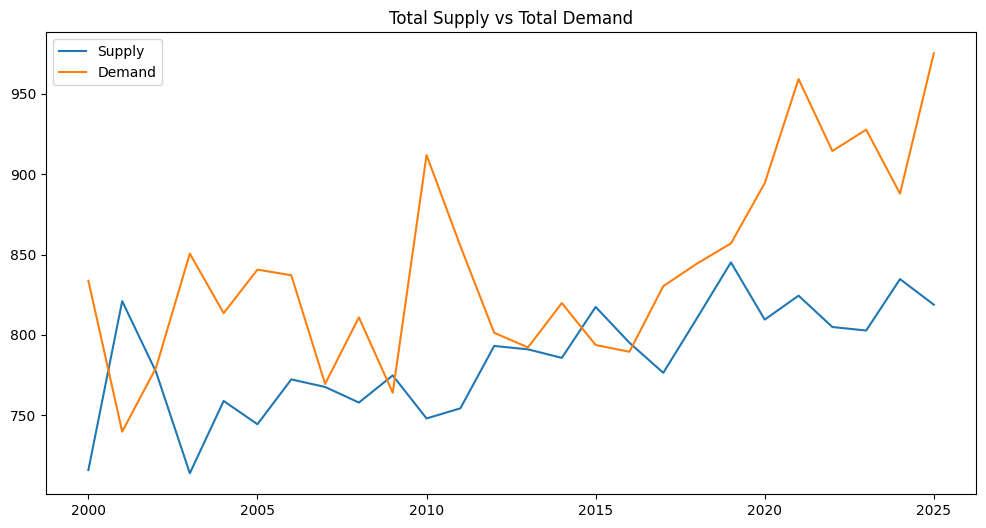

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    supply['Year'],
    supply['Total_Supply_MOz'],
    label='Supply'
)

plt.plot(
    supply['Year'],
    supply['Total_Demand_MOz'],
    label='Demand'
)

plt.legend()

plt.title(
    "Total Supply vs Total Demand"
)

plt.show()

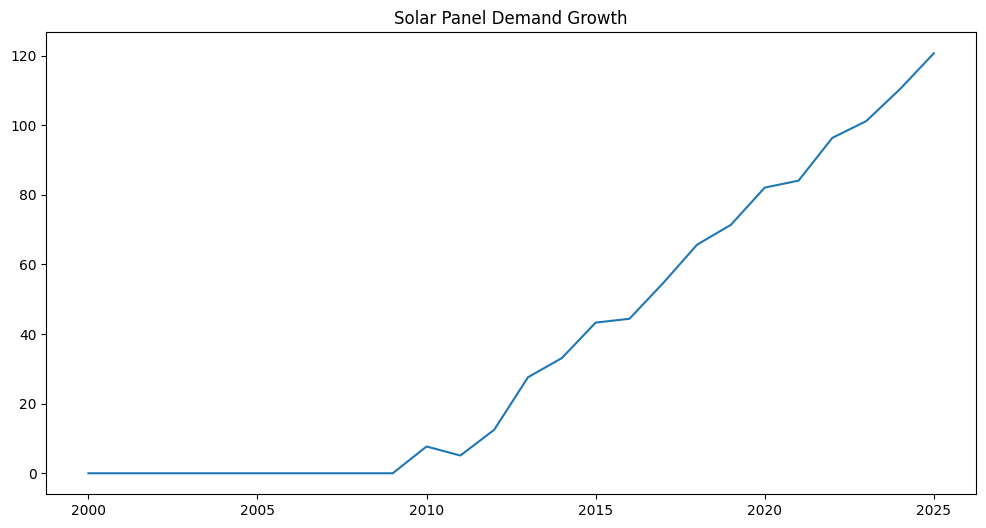

In [30]:
plt.figure(figsize=(12,6))

plt.plot(
    supply['Year'],
    supply['Solar_Panel_Demand_MOz']
)

plt.title(
    "Solar Panel Demand Growth"
)

plt.show()

# Final EDA Conclusions

1. Gold Price is the strongest macroeconomic predictor of silver prices.

2. DXY Index and Interest Rates show negative relationships with silver, confirming the influence of monetary policy and currency strength.

3. ETF Silver Holdings indicate that institutional investment demand significantly impacts silver prices.

4. Futures market variables such as Open Interest, Basis, and Implied Carry Rate provide valuable information regarding market expectations.

5. Social Media Mentions emerge as the most relevant sentiment indicator, while other sentiment variables have weaker relationships with price movements.

6. Industrial Demand, Solar Panel Demand, EV Demand, and Total Demand are key long-term drivers of silver prices.

7. The silver market is influenced by a combination of macroeconomic, fundamental, futures, and sentiment factors, making it suitable for multivariate forecasting approaches.

8. Based on the EDA results, the most promising features for predictive modeling are:
   - Gold_Price_USD
   - ETF_Silver_Holdings_MOz
   - DXY_Index
   - Fed_Funds_Rate
   - Open_Interest
   - Basis
   - Social_Media_Mentions
   - Industrial_Demand_MOz
   - Solar_Panel_Demand_MOz
   - EV_Demand_MOz

In [35]:
import pandas as pd

silver = pd.read_csv("silver_daily_ohclv_2000_2025.csv")
macro = pd.read_csv("silver_macroeconomic_monthly.csv")
sentiment = pd.read_csv("silver_sentiment_weekly.csv")

silver["Date"] = pd.to_datetime(silver["Date"])
macro["Date"] = pd.to_datetime(macro["Date"])
sentiment["Date"] = pd.to_datetime(sentiment["Date"])

print(silver.shape)
print(macro.shape)
print(sentiment.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'silver_daily_ohclv_2000_2025.csv'